# Proyecto Telecomunicaciones

Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.

### Servicios de Interconnect

Interconnect proporciona principalmente dos tipos de servicios:

1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
2. Internet. La red se puede configurar a través de una línea telefónica (DSL, *línea de abonado digital*) o a través de un cable de fibra óptica.

Algunos otros servicios que ofrece la empresa incluyen:

- Seguridad en Internet: software antivirus (*ProtecciónDeDispositivo*) y un bloqueador de sitios web maliciosos (*SeguridadEnLínea*).
- Una línea de soporte técnico (*SoporteTécnico*).
- Almacenamiento de archivos en la nube y backup de datos (*BackupOnline*).
- Streaming de TV (*StreamingTV*) y directorio de películas (*StreamingPelículas*)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

### Descripción de los datos

Los datos consisten en archivos obtenidos de diferentes fuentes:

- `contract.csv` — información del contrato;
- `personal.csv` — datos personales del cliente;
- `internet.csv` — información sobre los servicios de Internet;
- `phone.csv` — información sobre los servicios telefónicos.

En cada archivo, la columna `customerID` (ID de cliente) contiene un código único asignado a cada cliente. La información del contrato es válida a partir del 1 de febrero de 2020.

## Carga y Análisis Inicial de Datos

### Carga de Datos

Cargaremos los cuatro archivos CSV proporcionados en DataFrames de pandas para una manipulación y análisis más sencillos.

In [1]:
# Importar las librerías necesarias
import pandas as pd

In [ ]:
# Cargar los archivos CSV en DataFrames
df_contract = pd.read_csv('/aqui debes actualizar la ruta del archivo/contract.csv')
df_personal = pd.read_csv('/aqui debes actualizar la ruta del archivo/personal.csv')
df_internet = pd.read_csv('/aqui debes actualizar la ruta del archivo/internet.csv')
df_phone = pd.read_csv('/aqui debes actualizar la ruta del archivo/phone.csv')

print("Datos cargados exitosamente.")

Datos cargados exitosamente.


### Análisis Exploratorio de Datos (EDA) Inicial

Realizaremos un análisis inicial para entender la estructura, el tipo de datos y detectar posibles problemas en cada DataFrame.

#### DataFrame `df_contract` (Información del Contrato)

In [3]:
display(df_contract.head())
print(f"Shape de df_contract: {df_contract.shape}")
display(df_contract.info())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


Shape de df_contract: (7043, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


None

#### DataFrame `df_personal` (Datos Personales del Cliente)

In [4]:
display(df_personal.head())
print(f"Shape de df_personal: {df_personal.shape}")
display(df_personal.info())

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Shape de df_personal: (7043, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


None

#### DataFrame `df_internet` (Servicios de Internet)

In [5]:
display(df_internet.head())
print(f"Shape de df_internet: {df_internet.shape}")
display(df_internet.info())

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Shape de df_internet: (5517, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None

#### DataFrame `df_phone` (Servicios Telefónicos)

In [6]:
display(df_phone.head())
print(f"Shape de df_phone: {df_phone.shape}")
display(df_phone.info())

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Shape de df_phone: (6361, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None

## Unión, Limpieza y Modelado Inicial

### Verificación de `customerID` y Unión de DataFrames

Primero, verificaremos la unicidad de los IDs de cliente en cada conjunto de datos y luego los fusionaremos en un único DataFrame para tener una visión completa de cada cliente.

In [7]:
# Verificar la unicidad de customerID en cada DataFrame
print(f"customerID único en df_contract: {df_contract['customerID'].nunique() == len(df_contract)}")
print(f"customerID único en df_personal: {df_personal['customerID'].nunique() == len(df_personal)}")
print(f"customerID único en df_internet: {df_internet['customerID'].nunique() == len(df_internet)}")
print(f"customerID único en df_phone: {df_phone['customerID'].nunique() == len(df_phone)}")

# Obtener los IDs de cliente presentes en todos los DataFrames (para entender la cobertura)
all_customer_ids = pd.concat([
    df_contract['customerID'],
    df_personal['customerID'],
    df_internet['customerID'],
    df_phone['customerID']
]).unique()

print(f"\nNúmero total de customerID únicos en todos los archivos: {len(all_customer_ids)}")

# Unir los DataFrames
# Iniciamos con df_contract, ya que contiene la información central del cliente y el 'churn'
df_merged = df_contract.merge(df_personal, on='customerID', how='left')
# Los servicios de internet y teléfono son opcionales, por lo que usaremos un 'left merge'
# para mantener a todos los clientes del contrato, incluso si no tienen esos servicios.
df_merged = df_merged.merge(df_internet, on='customerID', how='left')
df_merged = df_merged.merge(df_phone, on='customerID', how='left')

print("\nDataFrames unidos exitosamente. Primeras 5 filas del DataFrame resultante:")
display(df_merged.head())
print("\nInformación del DataFrame unido:")
display(df_merged.info())


customerID único en df_contract: True
customerID único en df_personal: True
customerID único en df_internet: True
customerID único en df_phone: True

Número total de customerID únicos en todos los archivos: 7043

DataFrames unidos exitosamente. Primeras 5 filas del DataFrame resultante:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No



Información del DataFrame unido:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupp

None

### Limpieza y Preprocesamiento de Datos

Esta sección se enfocará en transformar los datos crudos en un formato adecuado para el modelado, manejando valores nulos, convirtiendo tipos de datos y realizando ingeniería de características.

#### Manejo de la variable objetivo `Churn` y `EndDate`

La columna `EndDate` contiene 'No' para clientes activos. Crearemos una variable `Churn` binaria (1 si el cliente se fue, 0 si está activo) y calcularemos la `Tenure` (antigüedad) del cliente.

In [8]:
# Convertir 'No' en EndDate a un valor que indique que el cliente sigue activo (ej. 'Activo')
df_merged['EndDate'] = df_merged['EndDate'].replace('No', 'Activo')

# Crear la variable objetivo 'Churn': 1 si 'EndDate' no es 'Activo', 0 si lo es.
df_merged['Churn'] = (df_merged['EndDate'] != 'Activo').astype(int)

# Convertir las fechas a formato datetime. Usamos errors='coerce' para manejar cualquier valor problemático.
df_merged['BeginDate'] = pd.to_datetime(df_merged['BeginDate'], errors='coerce')

# Para los clientes activos, usaremos la fecha más reciente de los datos para calcular la antigüedad (ej. 2020-02-01)
# La información del contrato es válida a partir del 1 de febrero de 2020.
df_merged['EndDate_dt'] = df_merged['EndDate'].replace('Activo', '2020-02-01') # Usamos la fecha de corte indicada

# Convertir EndDate_dt a datetime, inferir varios formatos y manejar errores.
df_merged['EndDate_dt'] = pd.to_datetime(df_merged['EndDate_dt'], errors='coerce', format='mixed')

# Calcular Tenure (antigüedad del cliente en meses)
# Rellenar NaNs resultantes de 'coerce' en las fechas con 0 antes de convertir a int
df_merged['Tenure'] = ((df_merged['EndDate_dt'] - df_merged['BeginDate']).dt.days / 30.41).fillna(0).astype(int)

# Eliminar las columnas de fecha originales que ya no necesitamos
df_merged = df_merged.drop(columns=['BeginDate', 'EndDate', 'EndDate_dt'])

display(df_merged[['customerID', 'Tenure', 'Churn']].head())

,customerID,Tenure,Churn
0,7590-VHVEG,1,0
1,5575-GNVDE,34,0
2,3668-QPYBK,2,1
3,7795-CFOCW,45,0
4,9237-HQITU,2,1


#### Manejo de `TotalCharges`

La columna `TotalCharges` es de tipo `object` y puede contener espacios vacíos que impiden su conversión directa a numérico. Los convertiremos a numéricos y manejaremos los valores faltantes o problemáticos.

In [9]:
# Convertir 'TotalCharges' a numérico. Los valores no numéricos se convertirán a NaN.
df_merged['TotalCharges'] = pd.to_numeric(df_merged['TotalCharges'], errors='coerce')

# Imputar valores NaN en TotalCharges. Dado que estos suelen corresponder a clientes nuevos con Tenure 0,
# imputaremos con 0. Verificaremos esto.
print("Número de NaN en TotalCharges antes de imputar:", df_merged['TotalCharges'].isnull().sum())

# Si hay NaN en TotalCharges, verificamos si coinciden con clientes con Tenure 0
nan_total_charges = df_merged[df_merged['TotalCharges'].isnull()]
print("Clientes con TotalCharges NaN y su Tenure:")
display(nan_total_charges[['customerID', 'Tenure', 'MonthlyCharges', 'TotalCharges']].head())

# Imputar NaN con 0
df_merged['TotalCharges'] = df_merged['TotalCharges'].fillna(0)

print("Número de NaN en TotalCharges después de imputar:", df_merged['TotalCharges'].isnull().sum())

Número de NaN en TotalCharges antes de imputar: 11
Clientes con TotalCharges NaN y su Tenure:


,customerID,Tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN


Número de NaN en TotalCharges después de imputar: 0


#### Manejo de Valores Nulos de Servicios

Los servicios de Internet y Teléfono se unieron usando un `left merge`. Esto significa que los clientes que no tienen un servicio particular (ej. Internet) tendrán valores `NaN` en las columnas de ese servicio. Imputaremos estos `NaN` con 'No' (para indicar que no tienen el servicio).

In [10]:
# Columnas relacionadas con servicios de Internet (todas son tipo 'object')
internet_service_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Columnas relacionadas con servicios de Teléfono (solo 'MultipleLines')
phone_service_cols = ['MultipleLines']

# Imputar NaN con 'No' en las columnas de servicios donde el cliente no tiene el servicio
for col in internet_service_cols:
    df_merged[col] = df_merged[col].fillna('No internet service') # Para InternetService, distinguimos
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_merged[col] = df_merged[col].fillna('No')

df_merged['MultipleLines'] = df_merged['MultipleLines'].fillna('No phone service') # Para MultipleLines, distinguimos

print("Recuento de valores nulos después de la imputación de servicios:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

# Reemplazar 'No internet service' y 'No phone service' por 'No' en los servicios correspondientes
# para evitar duplicidad en la codificación si 'No' ya existe para otros servicios
df_merged['InternetService'] = df_merged['InternetService'].replace('No internet service', 'No')
df_merged['MultipleLines'] = df_merged['MultipleLines'].replace('No phone service', 'No')

Recuento de valores nulos después de la imputación de servicios:
Series([], dtype: int64)


#### Codificación de Variables Categóricas

Convertiremos las variables categóricas a un formato numérico utilizando One-Hot Encoding, que es adecuado para la mayoría de los modelos de aprendizaje automático.

In [11]:
# Separar características (X) y variable objetivo (y)
X = df_merged.drop(columns=['customerID', 'Churn'])
y = df_merged['Churn']

# Identificar y eliminar columnas de tipo datetime si aún existen en X
datetime_cols = X.select_dtypes(include=['datetime64']).columns
if len(datetime_cols) > 0:
    X = X.drop(columns=datetime_cols)
    print(f"Columnas datetime eliminadas de X: {list(datetime_cols)}")

# Identificar columnas categóricas (ahora solo 'object' dtype)
categorical_cols = X.select_dtypes(include='object').columns

# Aplicar One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Primeras 5 filas del DataFrame con variables categóricas codificadas (y sin columnas de fecha):")
display(X_encoded.head())
print("Dimensiones del DataFrame codificado:", X_encoded.shape)


Primeras 5 filas del DataFrame con variables categóricas codificadas (y sin columnas de fecha):


,MonthlyCharges,TotalCharges,SeniorCitizen,Tenure,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,MultipleLines_Yes
0,29.85,29.85,0,1,False,False,True,False,True,False,...,True,False,False,False,False,False,False,False,False,False
1,56.95,1889.50,0,34,True,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
2,53.85,108.15,0,2,False,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,False
3,42.30,1840.75,0,45,True,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
4,70.70,151.65,0,2,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


Dimensiones del DataFrame codificado: (7043, 28)


#### Escalado de Características Numéricas

Escalaremos las características numéricas para asegurar que ninguna característica domine el proceso de entrenamiento del modelo debido a su magnitud.

In [12]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas que necesitan escalado (las que no son binarias y no fueron one-hot encoded)
# Excluimos las columnas de 'SeniorCitizen' que ya es 0/1
numeric_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Quitamos SeniorCitizen si está presente
if 'SeniorCitizen' in numeric_cols:
    numeric_cols.remove('SeniorCitizen')

scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print("Primeras 5 filas del DataFrame con características numéricas escaladas:")
display(X_encoded.head())


Primeras 5 filas del DataFrame con características numéricas escaladas:


,MonthlyCharges,TotalCharges,SeniorCitizen,Tenure,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,MultipleLines_Yes
0,-1.160323,-0.992611,0,-1.271807,False,False,True,False,True,False,...,True,False,False,False,False,False,False,False,False,False
1,-0.259629,-0.172165,0,0.068747,True,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
2,-0.362660,-0.958066,0,-1.231184,False,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,False
3,-0.746535,-0.193672,0,0.515598,True,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
4,0.197365,-0.938874,0,-1.231184,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


### Preparación para el Modelado: División de Datos

Dividiremos el conjunto de datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento de los modelos de manera imparcial.

In [13]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print(f"Distribución de Churn en y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Distribución de Churn en y_test:\n{y_test.value_counts(normalize=True)}")


Tamaño del conjunto de entrenamiento (X_train): (5634, 28)
Tamaño del conjunto de prueba (X_test): (1409, 28)
Distribución de Churn en y_train:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Distribución de Churn en y_test:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### Modelado Inicial y Evaluación

Implementaremos algunos de los modelos seleccionados para establecer una línea base y entender su rendimiento inicial.

#### Regresión Logística

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Inicializar y entrenar el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' es bueno para datasets pequeños y L1/L2
log_reg.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("--- Regresión Logística ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_log_reg):.4f}")


--- Regresión Logística ---
Accuracy: 0.8077

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC Score: 0.8444


#### Árbol de Decisión

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar y entrenar el modelo de Árbol de Decisión
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dec_tree = dec_tree.predict(X_test)
y_proba_dec_tree = dec_tree.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("--- Árbol de Decisión ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dec_tree):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dec_tree))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_dec_tree):.4f}")


--- Árbol de Decisión ---
Accuracy: 0.7452

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.52      0.51      0.52       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.74      1409

ROC AUC Score: 0.6709


#### Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo Random Forest
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rand_forest = rand_forest.predict(X_test)
y_proba_rand_forest = rand_forest.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rand_forest):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rand_forest))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rand_forest):.4f}")


--- Random Forest ---
Accuracy: 0.8027

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC Score: 0.8321


#### Gradient Boosting (LightGBM)

In [17]:
import lightgbm as lgb

# Inicializar y entrenar el modelo LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("--- LightGBM ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lgb):.4f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000625 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
--- LightGBM ---
Accuracy: 0.7991

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80   

### Comparación Visual de Modelos (Curvas ROC)

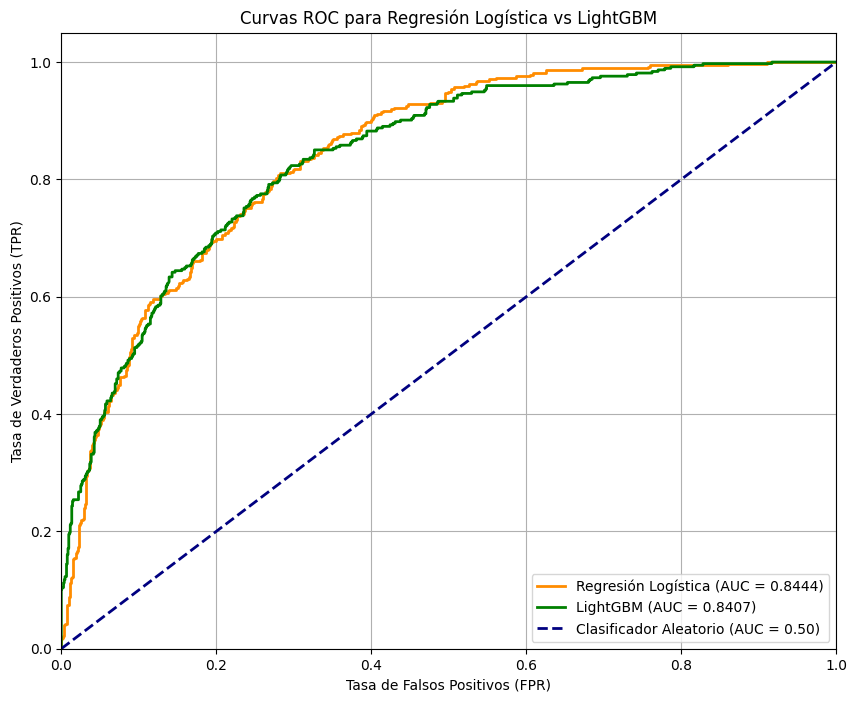

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Curva ROC para Regresión Logística
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_proba_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log_reg:.4f})')

# Curva ROC para LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)
plt.plot(fpr_lgb, tpr_lgb, color='green', lw=2, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC para Regresión Logística vs LightGBM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Resumen de los resultados y las métricas clave obtenidas de los modelos iniciales:

* Regresión Logística: Demostró un Accuracy de 0.8077 y un ROC AUC Score de 0.8444. Este modelo sirvió como una excelente línea base, mostrando un buen equilibrio general en su rendimiento.
* Árbol de Decisión: Registró un Accuracy de 0.7452 y un ROC AUC Score de 0.6709. Este fue el modelo con el rendimiento más bajo, lo que sugiere que podría necesitar una mayor optimización o que es menos adecuado para la complejidad de nuestros datos.
* Random Forest: Obtuvo un Accuracy de 0.8027 y un ROC AUC Score de 0.8321. Es un modelo robusto que superó al Árbol de Decisión y mostró un rendimiento sólido, cercano al de la Regresión Logística.
* LightGBM: Este potente algoritmo de Gradient Boosting logró un Accuracy de 0.7991 y un ROC AUC Score de 0.8407. Su rendimiento fue muy competitivo y similar al de la Regresión Logística, destacándose por su eficacia.

### Conclusión General:
Los modelos de Regresión Logística y LightGBM son los que ofrecen los mejores ROC AUC Scores, una métrica crucial para evaluar el rendimiento en problemas de clasificación de churn, donde las clases suelen estar desbalanceadas. Estos dos modelos son los candidatos más prometedores para futuras optimizaciones y un análisis más profundo en la siguiente etapa del proyecto. El Árbol de Decisión, por otro lado, se desempeñó por debajo de los demás, mientras que Random Forest proporcionó un rendimiento intermedio pero fiable.